# 🧠 LSTM — Long Short-Term Memory

Welcome back! We learned that vanilla RNNs struggle with **long sequences** because of vanishing gradients. The hidden state gets overwritten at every step, making it nearly impossible to remember information from far in the past.

LSTMs fix this with a brilliant idea: give the network a **separate memory lane** that information can flow through without being squished by activations.

## 🎯 What You'll Learn

By the end of this notebook, you'll understand:
- Why vanilla RNNs forget long-range information
- The **cell state** — the memory highway that fixes vanishing gradients
- The **three gates**: Forget, Input, and Output
- How to **build an LSTM cell from scratch** with NumPy
- How to **visualize gate activations** and understand what the LSTM is doing
- How LSTM compares to vanilla RNN on gradient flow
- A practical pattern-learning task: LSTM vs vanilla RNN

**Prerequisites:** Basic RNN understanding (how hidden states carry information through a sequence).

---

## 📖 Jargon Buster

| Term | Plain English Explanation |
|------|---------------------------|
| **Vanilla RNN** | The simplest recurrent neural network — just one hidden state updated at each step |
| **LSTM** | Long Short-Term Memory — an RNN with gates and a separate memory cell that can remember things for a long time |
| **Cell State** | The LSTM's long-term memory — a vector that flows through time with minimal changes, like a conveyor belt |
| **Hidden State** | The LSTM's short-term / working memory — what it outputs at each step |
| **Forget Gate** | Decides what to **throw away** from the cell state (values near 0 = forget, near 1 = keep) |
| **Input Gate** | Decides what **new information** to add to the cell state |
| **Output Gate** | Decides what part of the cell state to **output** as the hidden state |
| **Sigmoid** | A function that squashes values to [0, 1] — perfect for gates (0 = closed, 1 = open) |
| **Vanishing Gradient** | When gradients shrink to nearly zero during backpropagation through many time steps — the network can't learn long-range patterns |
| **Gradient Highway** | A path through the network where gradients can flow without being repeatedly multiplied by small numbers |
| **GRU** | Gated Recurrent Unit — a simpler alternative to LSTM with only two gates instead of three |

---

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

%matplotlib inline

np.random.seed(42)

print("✅ Libraries imported successfully!")
print("📦 NumPy version:", np.__version__)

✅ Libraries imported successfully!
📦 NumPy version: 1.26.4


---

## 💨 Part 1: The Problem with Vanilla RNNs

### 📝 The Telephone Game Analogy

Imagine a game of telephone with 50 people. The first person whispers a sentence, and each person passes it along. By the time it reaches person 50, the original message is completely garbled!

That's exactly what happens in a vanilla RNN. The hidden state is updated at **every** time step:

$$h_t = \tanh(W_{xh} \cdot x_t + W_{hh} \cdot h_{t-1} + b)$$

The problem? The `tanh` function squashes values into the range $[-1, 1]$. When you multiply by $W_{hh}$ and apply `tanh` over and over, 50 or 100 times, the original information gets **crushed to zero** (vanishing gradient) or **explodes to infinity** (exploding gradient).

Let's see this in action.

💨 THE VANISHING GRADIENT PROBLEM



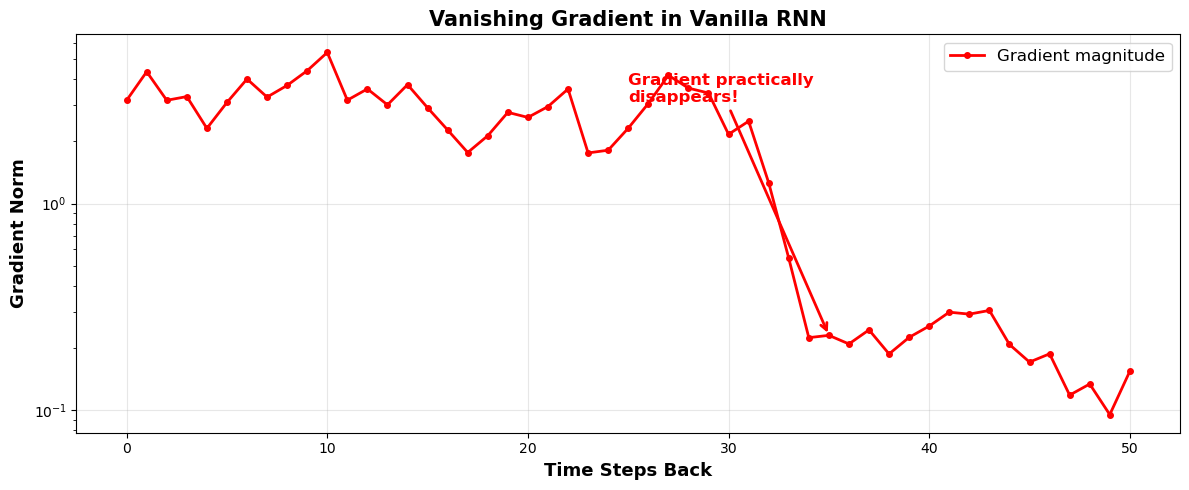


📊 Gradient norm at step 0:  3.1623
📊 Gradient norm at step 25: 2.3176e+00
📊 Gradient norm at step 50: 1.5442e-01

💡 The gradient shrinks EXPONENTIALLY. After 50 steps, it's essentially zero.
   This means the RNN CANNOT learn dependencies that span more than ~10-20 steps.


In [16]:
# Demonstrate the vanishing gradient problem

print("💨 THE VANISHING GRADIENT PROBLEM\n")
print("="*70)

# Simulate: what happens when you repeatedly multiply by a weight matrix
# and apply tanh? The gradient shrinks exponentially.

np.random.seed(42)
hidden_size = 10

# A typical weight matrix (values < 1 after tanh derivative)
W_hh = np.random.randn(hidden_size, hidden_size) * 0.5

# Track how a gradient signal decays over time steps
gradient = np.ones(hidden_size)  # start with a gradient of 1
gradient_norms = [np.linalg.norm(gradient)]

for t in range(50):
    # In backprop through tanh RNN, gradient gets multiplied by
    # diag(1 - tanh^2(h)) @ W_hh at each step
    # We simulate with a factor < 1
    tanh_derivative = 1 - np.tanh(np.random.randn(hidden_size))**2  # values in (0, 1)
    gradient = (tanh_derivative * gradient) @ W_hh
    gradient_norms.append(np.linalg.norm(gradient))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(gradient_norms, 'r-o', markersize=4, linewidth=2, label='Gradient magnitude')
ax.set_xlabel('Time Steps Back', fontsize=13, fontweight='bold')
ax.set_ylabel('Gradient Norm', fontsize=13, fontweight='bold')
ax.set_title('Vanishing Gradient in Vanilla RNN', fontsize=15, fontweight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)

# Annotate
ax.annotate('Gradient practically\ndisappears!', xy=(35, gradient_norms[35]),
            xytext=(25, gradient_norms[5]),
            arrowprops=dict(arrowstyle='->', lw=2, color='red'),
            fontsize=12, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Gradient norm at step 0:  {gradient_norms[0]:.4f}")
print(f"📊 Gradient norm at step 25: {gradient_norms[25]:.4e}")
print(f"📊 Gradient norm at step 50: {gradient_norms[50]:.4e}")
print(f"\n💡 The gradient shrinks EXPONENTIALLY. After 50 steps, it's essentially zero.")
print("   This means the RNN CANNOT learn dependencies that span more than ~10-20 steps.")
print("="*70)

---

## 🎬 Part 2: The LSTM Idea — A Conveyor Belt for Memory

### 🏭 The Factory Analogy

Imagine a factory assembly line. Workers at each station modify the product as it passes by. This is like a vanilla RNN — the hidden state gets **completely reworked** at every step.

Now imagine adding a **conveyor belt** that runs alongside the assembly line. Items on this belt flow freely from start to end. Workers can:
- **Remove** items from the belt (forget gate)
- **Add** new items to the belt (input gate)
- **Look at** items on the belt to decide what to do next (output gate)

But crucially, the belt itself **keeps moving** even if workers do nothing. Information can travel from the beginning of the factory to the end **without being transformed at every station**.

This conveyor belt is the **cell state** $C_t$ — the secret weapon of LSTMs.

### 🛣️ Why It Fixes Vanishing Gradients

In a vanilla RNN, gradients must pass through a `tanh` and a matrix multiply at every step. Each one shrinks the gradient.

In an LSTM, the cell state update is:

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

The gradient through $C_t$ with respect to $C_{t-1}$ is just $f_t$ (the forget gate) — **no matrix multiply, no tanh**. If $f_t \approx 1$, the gradient flows through **unchanged**. This is the "gradient highway."

/var/folders/98/5zng120j50n14r9zjqftvvq00000gn/T/ipykernel_12593/2302007620.py:77: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/98/5zng120j50n14r9zjqftvvq00000gn/T/ipykernel_12593/2302007620.py:77: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


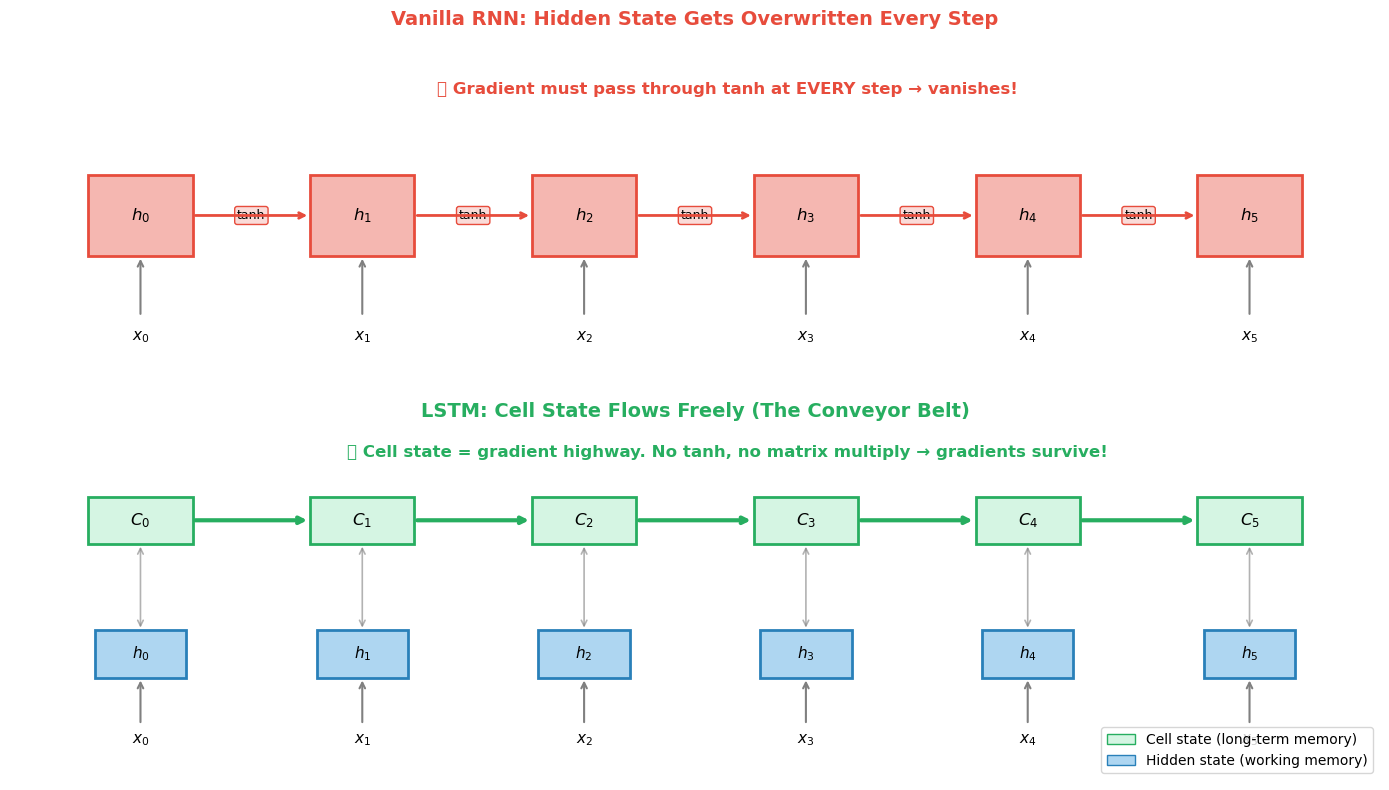


💡 KEY INSIGHT:
   Vanilla RNN: h_t = tanh(W @ h_{t-1} + ...) → gradient passes through tanh EVERY step
   LSTM:        C_t = f_t * C_{t-1} + ...     → gradient just multiplied by f_t (close to 1)
   This is why LSTMs can remember things over hundreds of time steps!


In [17]:
# Visualize the conveyor belt analogy

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# --- Vanilla RNN: hidden state gets overwritten ---
ax = axes[0]
ax.set_xlim(-0.5, 10)
ax.set_ylim(-0.5, 3)
ax.axis('off')
ax.set_title('Vanilla RNN: Hidden State Gets Overwritten Every Step',
             fontsize=14, fontweight='bold', color='#E74C3C')

for i in range(6):
    x = 0.5 + i * 1.7
    # Hidden state box
    rect = plt.Rectangle((x - 0.4, 0.8), 0.8, 0.8,
                          facecolor='#F5B7B1', edgecolor='#E74C3C', linewidth=2)
    ax.add_patch(rect)
    ax.text(x, 1.2, f'$h_{i}$', ha='center', va='center', fontsize=12, fontweight='bold')
    # tanh block
    if i < 5:
        mid_x = x + 0.85
        ax.text(mid_x, 1.2, 'tanh', ha='center', va='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#FADBD8', edgecolor='#E74C3C'))
        ax.annotate('', xy=(x + 1.3, 1.2), xytext=(x + 0.4, 1.2),
                    arrowprops=dict(arrowstyle='->', lw=2, color='#E74C3C'))
    # Input arrow
    ax.annotate('', xy=(x, 0.8), xytext=(x, 0.2),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='gray'))
    ax.text(x, 0.0, f'$x_{i}$', ha='center', va='center', fontsize=11)

ax.text(5, 2.4, '❌ Gradient must pass through tanh at EVERY step \u2192 vanishes!',
        ha='center', fontsize=12, color='#E74C3C', fontweight='bold')

# --- LSTM: cell state flows freely ---
ax = axes[1]
ax.set_xlim(-0.5, 10)
ax.set_ylim(-0.5, 4)
ax.axis('off')
ax.set_title('LSTM: Cell State Flows Freely (The Conveyor Belt)',
             fontsize=14, fontweight='bold', color='#27AE60')

for i in range(6):
    x = 0.5 + i * 1.7
    # Cell state (top belt)
    rect_c = plt.Rectangle((x - 0.4, 2.5), 0.8, 0.6,
                            facecolor='#D5F5E3', edgecolor='#27AE60', linewidth=2)
    ax.add_patch(rect_c)
    ax.text(x, 2.8, f'$C_{i}$', ha='center', va='center', fontsize=12, fontweight='bold')
    # Arrow along cell state (the highway)
    if i < 5:
        ax.annotate('', xy=(x + 1.3, 2.8), xytext=(x + 0.4, 2.8),
                    arrowprops=dict(arrowstyle='->', lw=3, color='#27AE60'))
    # Hidden state (below)
    rect_h = plt.Rectangle((x - 0.35, 0.8), 0.7, 0.6,
                            facecolor='#AED6F1', edgecolor='#2980B9', linewidth=2)
    ax.add_patch(rect_h)
    ax.text(x, 1.1, f'$h_{i}$', ha='center', va='center', fontsize=11)
    # Input
    ax.annotate('', xy=(x, 0.8), xytext=(x, 0.2),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='gray'))
    ax.text(x, 0.0, f'$x_{i}$', ha='center', va='center', fontsize=11)
    # Interaction arrow (h <-> C)
    ax.annotate('', xy=(x, 2.5), xytext=(x, 1.4),
                arrowprops=dict(arrowstyle='<->', lw=1.2, color='gray', alpha=0.6))

ax.text(5, 3.6, '✅ Cell state = gradient highway. No tanh, no matrix multiply \u2192 gradients survive!',
        ha='center', fontsize=12, color='#27AE60', fontweight='bold')

# Legend
legend_elements = [
    mpatches.Patch(facecolor='#D5F5E3', edgecolor='#27AE60', label='Cell state (long-term memory)'),
    mpatches.Patch(facecolor='#AED6F1', edgecolor='#2980B9', label='Hidden state (working memory)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

print("\n💡 KEY INSIGHT:")
print("   Vanilla RNN: h_t = tanh(W @ h_{t-1} + ...) \u2192 gradient passes through tanh EVERY step")
print("   LSTM:        C_t = f_t * C_{t-1} + ...     \u2192 gradient just multiplied by f_t (close to 1)")
print("   This is why LSTMs can remember things over hundreds of time steps!")

---

## 🚪 Part 3: The Three Gates

An LSTM cell has **three gates** that control the flow of information. Each gate is a sigmoid layer that outputs values between 0 and 1:
- **0** = "completely block this" (gate closed)
- **1** = "completely let this through" (gate open)

Let's build each one step by step.

### Gate 1: The Forget Gate $f_t$ 🗑️

**Question it answers:** "What should I **throw away** from the cell state?"

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

The forget gate looks at the previous hidden state $h_{t-1}$ and the current input $x_t$, and outputs a number between 0 and 1 for each element of the cell state. A value of 0 means "completely forget this," and 1 means "completely keep this."

**Analogy:** You're reading a story. You encounter "The main character moved to Paris." The forget gate says: "Forget the old city name, we have a new one."

### Gate 2: The Input Gate $i_t$ 📥

**Question it answers:** "What **new information** should I store in the cell state?"

This is actually two parts:

$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \quad \text{(what to update)}$$
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C) \quad \text{(candidate new values)}$$

The input gate $i_t$ decides **which** values to update (0 or 1), and $\tilde{C}_t$ creates **candidate** new values. They're multiplied together so only the selected new information gets added.

**Analogy:** "We just learned the character's name is Alice. The input gate says: 'Write this down in the name field.'"

### Gate 3: The Output Gate $o_t$ 📤

**Question it answers:** "What part of the cell state should I **output** right now?"

$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(C_t)$$

The cell state contains everything we've memorized, but we don't always need to output all of it. The output gate filters what's relevant **right now**.

**Analogy:** Your brain stores thousands of facts, but when someone asks "What's 2+2?" the output gate only lets the math knowledge through, not your grocery list.

In [18]:
# Demonstrate each gate with a simple example

def sigmoid(x):
    """Sigmoid activation: squashes values to [0, 1]."""
    return 1 / (1 + np.exp(-x))

print("🚪 THE THREE GATES \u2014 Step by Step Demo\n")
print("="*70)

# Simple example: 2D hidden state, 2D input
np.random.seed(42)
h_prev = np.array([0.5, -0.3])   # previous hidden state
x_t = np.array([1.0, 0.2])       # current input

# Concatenate [h_prev, x_t] - this is what all gates see
combined = np.concatenate([h_prev, x_t])
print(f"Previous hidden state h_{{t-1}}: {h_prev}")
print(f"Current input x_t:             {x_t}")
print(f"Concatenated [h_{{t-1}}, x_t]:   {combined}")

# Gate weights (small random values for demo)
W_f = np.random.randn(2, 4) * 0.5  # forget gate
W_i = np.random.randn(2, 4) * 0.5  # input gate
W_C = np.random.randn(2, 4) * 0.5  # candidate
W_o = np.random.randn(2, 4) * 0.5  # output gate
b_f = np.zeros(2)
b_i = np.zeros(2)
b_C = np.zeros(2)
b_o = np.zeros(2)

print("\n" + "-"*70)

# FORGET GATE
f_t = sigmoid(W_f @ combined + b_f)
print(f"\n🗑\ufe0f  Forget Gate f_t = sigmoid(W_f @ [h, x] + b_f)")
print(f"   f_t = {f_t}")
print(f"   Interpretation: Keep {f_t[0]*100:.1f}% of memory slot 0, {f_t[1]*100:.1f}% of slot 1")

# INPUT GATE
i_t = sigmoid(W_i @ combined + b_i)
C_candidate = np.tanh(W_C @ combined + b_C)
print(f"\n📥 Input Gate i_t = sigmoid(W_i @ [h, x] + b_i)")
print(f"   i_t = {i_t}")
print(f"   Candidate new values C~ = tanh(W_C @ [h, x] + b_C)")
print(f"   C~ = {C_candidate}")
print(f"   New info to add: i_t * C~ = {i_t * C_candidate}")

# UPDATE CELL STATE
C_prev = np.array([0.8, -0.5])  # previous cell state
C_t = f_t * C_prev + i_t * C_candidate
print(f"\n📦 Cell State Update")
print(f"   C_{{t-1}} = {C_prev}")
print(f"   C_t = f_t * C_{{t-1}} + i_t * C~")
print(f"   C_t = {f_t} * {C_prev} + {i_t * C_candidate}")
print(f"   C_t = {C_t}")

# OUTPUT GATE
o_t = sigmoid(W_o @ combined + b_o)
h_t = o_t * np.tanh(C_t)
print(f"\n📤 Output Gate o_t = sigmoid(W_o @ [h, x] + b_o)")
print(f"   o_t = {o_t}")
print(f"   h_t = o_t * tanh(C_t) = {o_t} * {np.tanh(C_t)}")
print(f"   h_t = {h_t}")

print("\n" + "="*70)
print("\n💡 Summary of one LSTM step:")
print(f"   Input:  h_{{t-1}} = {h_prev}, x_t = {x_t}, C_{{t-1}} = {C_prev}")
print(f"   Output: h_t = {h_t}, C_t = {C_t}")
print("="*70)

🚪 THE THREE GATES — Step by Step Demo

Previous hidden state h_{t-1}: [ 0.5 -0.3]
Current input x_t:             [1.  0.2]
Concatenated [h_{t-1}, x_t]:   [ 0.5 -0.3  1.   0.2]

----------------------------------------------------------------------

🗑️  Forget Gate f_t = sigmoid(W_f @ [h, x] + b_f)
   f_t = [0.65046083 0.69908239]
   Interpretation: Keep 65.0% of memory slot 0, 69.9% of slot 1

📥 Input Gate i_t = sigmoid(W_i @ [h, x] + b_i)
   i_t = [0.38295265 0.36095881]
   Candidate new values C~ = tanh(W_C @ [h, x] + b_C)
   C~ = [-0.71414245  0.28357729]
   New info to add: i_t * C~ = [-0.27348274  0.10235972]

📦 Cell State Update
   C_{t-1} = [ 0.8 -0.5]
   C_t = f_t * C_{t-1} + i_t * C~
   C_t = [0.65046083 0.69908239] * [ 0.8 -0.5] + [-0.27348274  0.10235972]
   C_t = [ 0.24688592 -0.24718147]

📤 Output Gate o_t = sigmoid(W_o @ [h, x] + b_o)
   o_t = [0.33388603 0.44471914]
   h_t = o_t * tanh(C_t) = [0.33388603 0.44471914] * [ 0.24198916 -0.24226738]
   h_t = [ 0.0807968  -0.10

Font 'default' does not have a glyph for '\U0001f4a1' [U+1f4a1], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\U0001f4a1' [U+1f4a1], substituting with a dummy symbol.


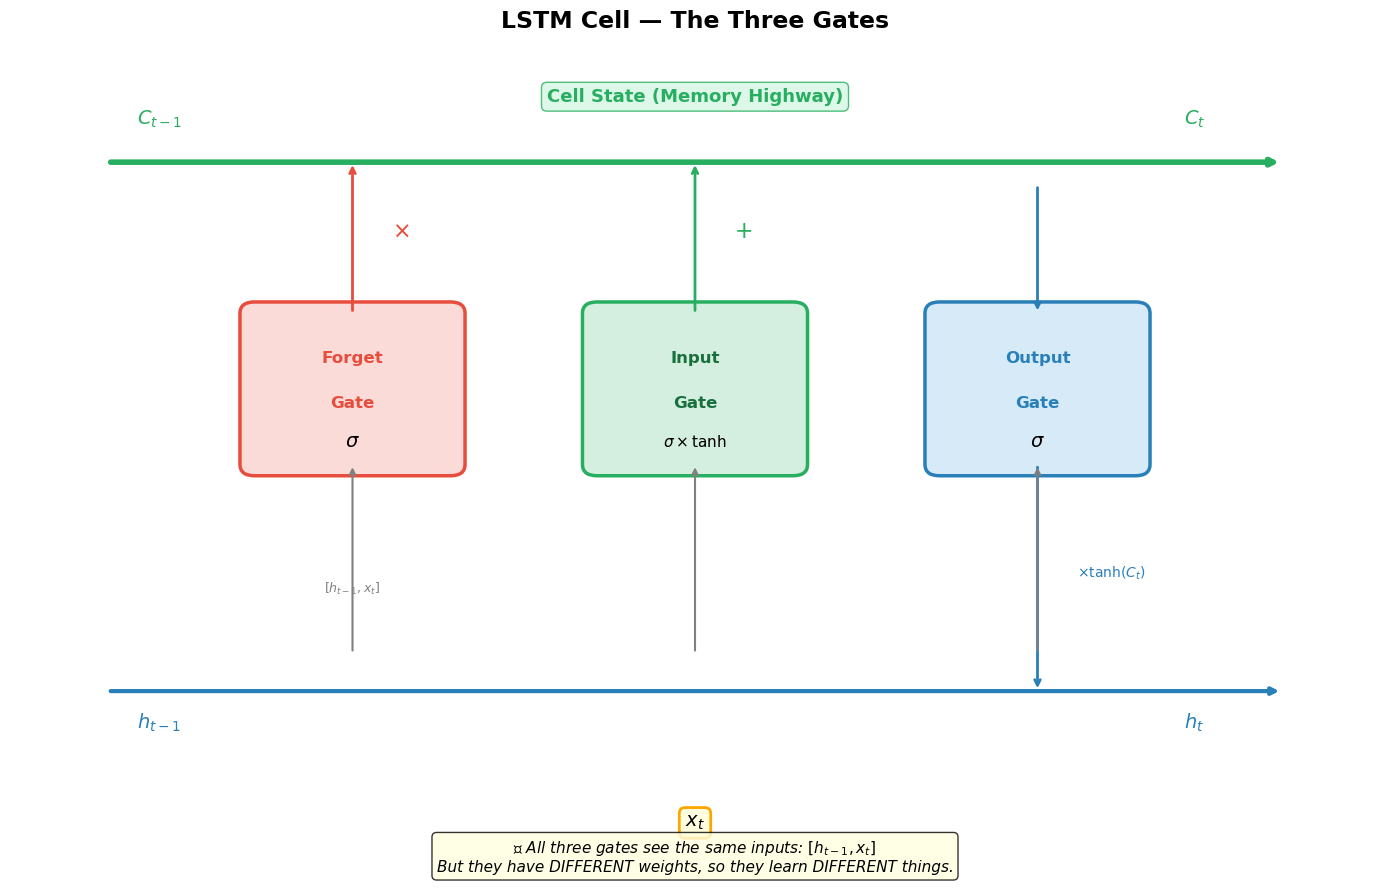


📝 Gate Summary:
   🗑️  Forget Gate (red):  Decides what to ERASE from the cell state
   📥 Input Gate (green):  Decides what NEW info to WRITE to the cell state
   📤 Output Gate (blue):  Decides what to OUTPUT as the hidden state


In [19]:
# Draw a clear diagram of the LSTM cell with all three gates

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(-1, 13)
ax.set_ylim(-1, 10)
ax.axis('off')
ax.set_title('LSTM Cell \u2014 The Three Gates', fontsize=17, fontweight='bold', pad=15)

# Cell state highway (top)
ax.annotate('', xy=(12, 8.5), xytext=(0, 8.5),
            arrowprops=dict(arrowstyle='->', lw=4, color='#27AE60'))
ax.text(0.3, 9.0, '$C_{t-1}$', fontsize=14, fontweight='bold', color='#27AE60')
ax.text(11.0, 9.0, '$C_t$', fontsize=14, fontweight='bold', color='#27AE60')
ax.text(6, 9.3, 'Cell State (Memory Highway)', ha='center', fontsize=13,
        fontweight='bold', color='#27AE60',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#D5F5E3', edgecolor='#27AE60', alpha=0.8))

# Hidden state (bottom)
ax.annotate('', xy=(12, 1.5), xytext=(0, 1.5),
            arrowprops=dict(arrowstyle='->', lw=3, color='#2980B9'))
ax.text(0.3, 1.0, '$h_{t-1}$', fontsize=14, fontweight='bold', color='#2980B9')
ax.text(11.0, 1.0, '$h_t$', fontsize=14, fontweight='bold', color='#2980B9')

# Input at bottom
ax.text(6, -0.3, '$x_t$', fontsize=14, fontweight='bold', ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='orange', linewidth=2))

# FORGET GATE (left)
forget_box = mpatches.FancyBboxPatch((1.5, 4.5), 2.0, 2.0, boxstyle='round,pad=0.15',
                                      facecolor='#FADBD8', edgecolor='#E74C3C', linewidth=2.5)
ax.add_patch(forget_box)
ax.text(2.5, 5.9, 'Forget', ha='center', va='center', fontsize=12, fontweight='bold', color='#E74C3C')
ax.text(2.5, 5.3, 'Gate', ha='center', va='center', fontsize=12, fontweight='bold', color='#E74C3C')
ax.text(2.5, 4.8, '$\\sigma$', ha='center', va='center', fontsize=14)
# Forget gate connection to cell state
ax.annotate('', xy=(2.5, 8.5), xytext=(2.5, 6.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='#E74C3C'))
ax.text(2.9, 7.5, '$\\times$', fontsize=16, color='#E74C3C', fontweight='bold')
# Arrow from h,x to forget gate
ax.annotate('', xy=(2.5, 4.5), xytext=(2.5, 2.0),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='gray'))
ax.text(2.5, 2.8, '$[h_{t-1}, x_t]$', ha='center', fontsize=9, color='gray')

# INPUT GATE (middle)
input_box = mpatches.FancyBboxPatch((5.0, 4.5), 2.0, 2.0, boxstyle='round,pad=0.15',
                                     facecolor='#D4EFDF', edgecolor='#27AE60', linewidth=2.5)
ax.add_patch(input_box)
ax.text(6.0, 5.9, 'Input', ha='center', va='center', fontsize=12, fontweight='bold', color='#196F3D')
ax.text(6.0, 5.3, 'Gate', ha='center', va='center', fontsize=12, fontweight='bold', color='#196F3D')
ax.text(6.0, 4.8, '$\\sigma \\times \\tanh$', ha='center', va='center', fontsize=11)
# Input gate connection to cell state
ax.annotate('', xy=(6.0, 8.5), xytext=(6.0, 6.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='#27AE60'))
ax.text(6.4, 7.5, '$+$', fontsize=16, color='#27AE60', fontweight='bold')
# Arrow from h,x to input gate
ax.annotate('', xy=(6.0, 4.5), xytext=(6.0, 2.0),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='gray'))

# OUTPUT GATE (right)
output_box = mpatches.FancyBboxPatch((8.5, 4.5), 2.0, 2.0, boxstyle='round,pad=0.15',
                                      facecolor='#D6EAF8', edgecolor='#2980B9', linewidth=2.5)
ax.add_patch(output_box)
ax.text(9.5, 5.9, 'Output', ha='center', va='center', fontsize=12, fontweight='bold', color='#2980B9')
ax.text(9.5, 5.3, 'Gate', ha='center', va='center', fontsize=12, fontweight='bold', color='#2980B9')
ax.text(9.5, 4.8, '$\\sigma$', ha='center', va='center', fontsize=14)
# Output gate connection from cell state to hidden state
ax.annotate('', xy=(9.5, 6.5), xytext=(9.5, 8.2),
            arrowprops=dict(arrowstyle='->', lw=2, color='#2980B9'))
ax.annotate('', xy=(9.5, 1.5), xytext=(9.5, 4.5),
            arrowprops=dict(arrowstyle='->', lw=2, color='#2980B9'))
ax.text(9.9, 3.0, '$\\times \\tanh(C_t)$', fontsize=10, color='#2980B9')
# Arrow from h,x to output gate
ax.annotate('', xy=(9.5, 4.5), xytext=(9.5, 2.0),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='gray'))

# Bottom label
ax.text(6, -0.9, '💡 All three gates see the same inputs: $[h_{t-1}, x_t]$\n'
        'But they have DIFFERENT weights, so they learn DIFFERENT things.',
        ha='center', fontsize=11, fontstyle='italic',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n📝 Gate Summary:")
print("   🗑\ufe0f  Forget Gate (red):  Decides what to ERASE from the cell state")
print("   📥 Input Gate (green):  Decides what NEW info to WRITE to the cell state")
print("   📤 Output Gate (blue):  Decides what to OUTPUT as the hidden state")

---

## 🛣️ Part 4: Cell State — The Memory Highway

The cell state update is the heart of the LSTM:

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

Let's break this down:

1. **$f_t \odot C_{t-1}$**: Take the old cell state and multiply it element-wise by the forget gate. This **erases** things we want to forget. If $f_t = 1$, keep everything. If $f_t = 0$, forget everything.

2. **$i_t \odot \tilde{C}_t$**: Take the candidate new values and multiply by the input gate. This **adds** new information. If $i_t = 1$, add all the new info. If $i_t = 0$, add nothing.

3. **$+$**: The old (filtered) memory and new information are simply **added together**.

### 🎯 Why This Fixes Vanishing Gradients

During backpropagation, we need $\frac{\partial C_t}{\partial C_{t-1}}$. From the equation above:

$$\frac{\partial C_t}{\partial C_{t-1}} = f_t$$

That's it! Just the forget gate value. No weight matrix multiply. No tanh squashing. If the forget gate is close to 1, the gradient flows through **perfectly**. Over 100 time steps, the gradient is roughly $f_1 \times f_2 \times \cdots \times f_{100}$. If each $f_t \approx 0.99$, that product is still about $0.99^{100} \approx 0.37$ — much better than the near-zero values in vanilla RNNs!

🛣️ CELL STATE: THE GRADIENT HIGHWAY



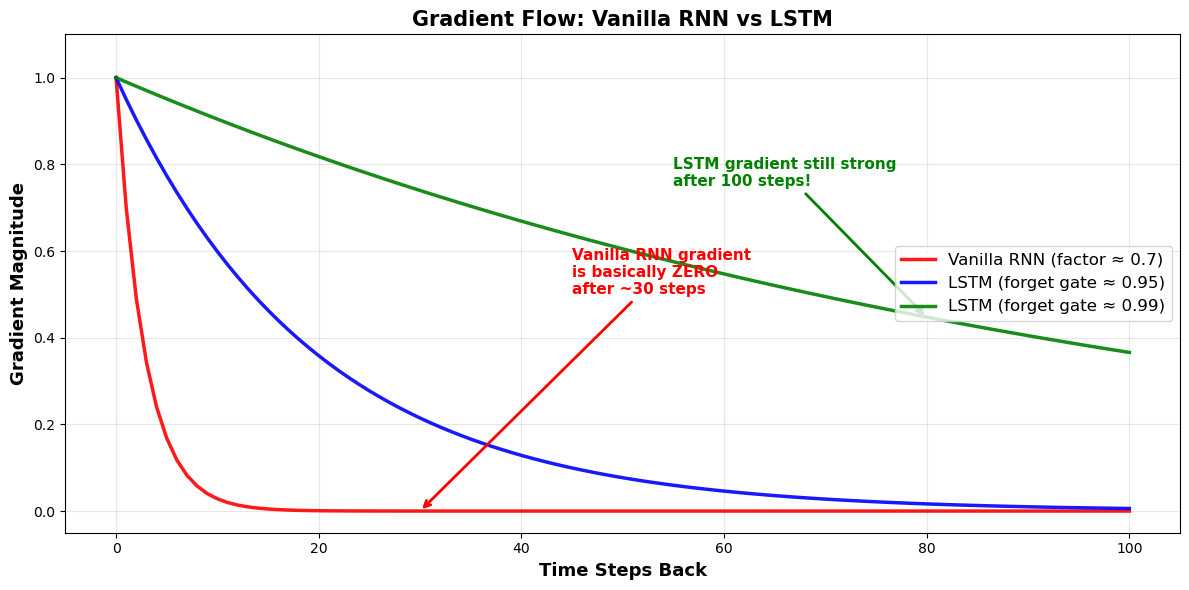


📊 After 100 steps:
   Vanilla RNN gradient: 3.23e-16  (practically zero)
   LSTM (f=0.95):        0.0059  (still meaningful!)
   LSTM (f=0.99):        0.3660  (very healthy!)

💡 The cell state is a HIGHWAY for gradients.
   No tanh, no matrix multiply — just multiplication by the forget gate.
   The network LEARNS to keep the forget gate open when long-range memory matters.


In [20]:
# Demonstrate: gradient flow through cell state vs vanilla RNN

print("🛣\ufe0f CELL STATE: THE GRADIENT HIGHWAY\n")
print("="*70)

n_steps = 100

# Vanilla RNN: gradient decays through tanh derivative * weight matrix
# Simplified: multiply by ~0.7 each step (typical tanh derivative * weight magnitude)
vanilla_gradient = [1.0]
for t in range(n_steps):
    vanilla_gradient.append(vanilla_gradient[-1] * 0.7)

# LSTM cell state: gradient decays through forget gate only
# With forget gate ~0.99 (network learns to keep gate open for important info)
lstm_gradient_099 = [1.0]
for t in range(n_steps):
    lstm_gradient_099.append(lstm_gradient_099[-1] * 0.99)

# LSTM with forget gate ~0.95
lstm_gradient_095 = [1.0]
for t in range(n_steps):
    lstm_gradient_095.append(lstm_gradient_095[-1] * 0.95)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(vanilla_gradient, 'r-', linewidth=2.5, label='Vanilla RNN (factor \u2248 0.7)', alpha=0.9)
ax.plot(lstm_gradient_095, 'b-', linewidth=2.5, label='LSTM (forget gate \u2248 0.95)', alpha=0.9)
ax.plot(lstm_gradient_099, 'g-', linewidth=2.5, label='LSTM (forget gate \u2248 0.99)', alpha=0.9)

ax.set_xlabel('Time Steps Back', fontsize=13, fontweight='bold')
ax.set_ylabel('Gradient Magnitude', fontsize=13, fontweight='bold')
ax.set_title('Gradient Flow: Vanilla RNN vs LSTM', fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='center right')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)

# Annotations
ax.annotate('Vanilla RNN gradient\nis basically ZERO\nafter ~30 steps', xy=(30, vanilla_gradient[30]),
            xytext=(45, 0.5), arrowprops=dict(arrowstyle='->', lw=2, color='red'),
            fontsize=11, color='red', fontweight='bold')

ax.annotate('LSTM gradient still strong\nafter 100 steps!', xy=(80, lstm_gradient_099[80]),
            xytext=(55, 0.75), arrowprops=dict(arrowstyle='->', lw=2, color='green'),
            fontsize=11, color='green', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 After 100 steps:")
print(f"   Vanilla RNN gradient: {vanilla_gradient[100]:.2e}  (practically zero)")
print(f"   LSTM (f=0.95):        {lstm_gradient_095[100]:.4f}  (still meaningful!)")
print(f"   LSTM (f=0.99):        {lstm_gradient_099[100]:.4f}  (very healthy!)")
print(f"\n💡 The cell state is a HIGHWAY for gradients.")
print(f"   No tanh, no matrix multiply \u2014 just multiplication by the forget gate.")
print(f"   The network LEARNS to keep the forget gate open when long-range memory matters.")

---

## 🛠️ Part 5: LSTM Cell From Scratch

Now let's build a complete LSTM cell in NumPy. Here are all the equations together:

**Inputs at each step:** $x_t$ (input), $h_{t-1}$ (previous hidden state), $C_{t-1}$ (previous cell state)

**Gates:**
$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \quad \text{(forget gate)}$$
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \quad \text{(input gate)}$$
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \quad \text{(output gate)}$$

**Cell state update:**
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C) \quad \text{(candidate values)}$$
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

**Hidden state output:**
$$h_t = o_t \odot \tanh(C_t)$$

In [21]:
class LSTMCell:
    """
    A single LSTM cell built from scratch with NumPy.
    
    At each time step it takes:
      - x_t:    current input
      - h_prev: previous hidden state
      - C_prev: previous cell state
    
    And produces:
      - h_t: new hidden state (output)
      - C_t: new cell state (long-term memory)
    """
    
    def __init__(self, input_size, hidden_size):
        """
        Parameters:
        - input_size:  dimension of each input vector x_t
        - hidden_size: dimension of the hidden state h_t (and cell state C_t)
        """
        self.input_size = input_size
        self.hidden_size = hidden_size
        
        # Combined input size: [h_{t-1}, x_t]
        combined_size = hidden_size + input_size
        
        # Xavier initialization for all four weight matrices
        scale = np.sqrt(2.0 / (combined_size + hidden_size))
        
        # Forget gate weights and bias
        self.W_f = np.random.randn(hidden_size, combined_size) * scale
        self.b_f = np.ones(hidden_size) * 1.0  # Initialize forget bias to 1 (keep memory by default)
        
        # Input gate weights and bias
        self.W_i = np.random.randn(hidden_size, combined_size) * scale
        self.b_i = np.zeros(hidden_size)
        
        # Candidate cell state weights and bias
        self.W_C = np.random.randn(hidden_size, combined_size) * scale
        self.b_C = np.zeros(hidden_size)
        
        # Output gate weights and bias
        self.W_o = np.random.randn(hidden_size, combined_size) * scale
        self.b_o = np.zeros(hidden_size)
    
    def forward_step(self, x_t, h_prev, C_prev):
        """
        One time step of the LSTM.
        
        Parameters:
        - x_t:    input at time t, shape (input_size,)
        - h_prev: hidden state from time t-1, shape (hidden_size,)
        - C_prev: cell state from time t-1, shape (hidden_size,)
        
        Returns:
        - h_t:    new hidden state, shape (hidden_size,)
        - C_t:    new cell state, shape (hidden_size,)
        - gates:  dict with gate values (for visualization)
        """
        # Concatenate h_{t-1} and x_t
        combined = np.concatenate([h_prev, x_t])
        
        # Forget gate: what to erase from cell state
        f_t = sigmoid(self.W_f @ combined + self.b_f)
        
        # Input gate: what new info to add
        i_t = sigmoid(self.W_i @ combined + self.b_i)
        
        # Candidate new cell values
        C_candidate = np.tanh(self.W_C @ combined + self.b_C)
        
        # Update cell state: forget old + add new
        C_t = f_t * C_prev + i_t * C_candidate
        
        # Output gate: what to output
        o_t = sigmoid(self.W_o @ combined + self.b_o)
        
        # New hidden state
        h_t = o_t * np.tanh(C_t)
        
        # Store gate values for visualization
        gates = {
            'f': f_t,           # forget gate
            'i': i_t,           # input gate
            'o': o_t,           # output gate
            'C_candidate': C_candidate,  # candidate values
            'C': C_t,           # cell state
        }
        
        return h_t, C_t, gates
    
    def forward_sequence(self, X):
        """
        Run the LSTM over an entire sequence.
        
        Parameters:
        - X: input sequence, shape (seq_len, input_size)
        
        Returns:
        - hidden_states: array of shape (seq_len, hidden_size)
        - cell_states:   array of shape (seq_len, hidden_size)
        - all_gates:     list of gate dicts at each step
        """
        seq_len = X.shape[0]
        
        # Initialize hidden and cell states to zeros
        h = np.zeros(self.hidden_size)
        C = np.zeros(self.hidden_size)
        
        hidden_states = []
        cell_states = []
        all_gates = []
        
        for t in range(seq_len):
            h, C, gates = self.forward_step(X[t], h, C)
            hidden_states.append(h.copy())
            cell_states.append(C.copy())
            all_gates.append(gates)
        
        return np.array(hidden_states), np.array(cell_states), all_gates


print("✅ LSTMCell class defined!")
print("\n📋 Parameters per LSTM cell:")
print("   - W_f, b_f  (forget gate)")
print("   - W_i, b_i  (input gate)")
print("   - W_C, b_C  (candidate cell values)")
print("   - W_o, b_o  (output gate)")
print("   = 4 weight matrices + 4 bias vectors")
print("   That's 4x the parameters of a vanilla RNN!")

✅ LSTMCell class defined!

📋 Parameters per LSTM cell:
   - W_f, b_f  (forget gate)
   - W_i, b_i  (input gate)
   - W_C, b_C  (candidate cell values)
   - W_o, b_o  (output gate)
   = 4 weight matrices + 4 bias vectors
   That's 4x the parameters of a vanilla RNN!


In [22]:
# Test the LSTM cell and show all shapes

print("🧪 TESTING THE LSTM CELL\n")
print("="*70)

np.random.seed(42)

input_size = 4
hidden_size = 6
seq_len = 8

# Create LSTM
lstm = LSTMCell(input_size, hidden_size)

# Random input sequence
X = np.random.randn(seq_len, input_size)

print(f"Configuration:")
print(f"   Input size:  {input_size}")
print(f"   Hidden size: {hidden_size}")
print(f"   Sequence length: {seq_len}")

# Show weight shapes
combined_size = hidden_size + input_size
print(f"\n📏 Weight Shapes (all gates see [{hidden_size} + {input_size}] = {combined_size} inputs):")
print(f"   W_f (forget gate):  {lstm.W_f.shape}  ({hidden_size} x {combined_size})")
print(f"   W_i (input gate):   {lstm.W_i.shape}  ({hidden_size} x {combined_size})")
print(f"   W_C (candidate):    {lstm.W_C.shape}  ({hidden_size} x {combined_size})")
print(f"   W_o (output gate):  {lstm.W_o.shape}  ({hidden_size} x {combined_size})")

total_params = 4 * hidden_size * combined_size + 4 * hidden_size
print(f"\n   Total parameters: {total_params}")
print(f"   (4 matrices of {hidden_size}x{combined_size} + 4 biases of {hidden_size})")

# Run forward pass
hidden_states, cell_states, all_gates = lstm.forward_sequence(X)

print(f"\n📊 Forward Pass Results:")
print(f"   Input shape:         {X.shape}")
print(f"   Hidden states shape: {hidden_states.shape}")
print(f"   Cell states shape:   {cell_states.shape}")
print(f"   Number of gate snapshots: {len(all_gates)}")

# Show one time step
print(f"\n🔍 Gate values at time step 0:")
g = all_gates[0]
print(f"   Forget gate: {g['f'][:3]}... (range: {g['f'].min():.3f} to {g['f'].max():.3f})")
print(f"   Input gate:  {g['i'][:3]}... (range: {g['i'].min():.3f} to {g['i'].max():.3f})")
print(f"   Output gate: {g['o'][:3]}... (range: {g['o'].min():.3f} to {g['o'].max():.3f})")
print("="*70)

🧪 TESTING THE LSTM CELL

Configuration:
   Input size:  4
   Hidden size: 6
   Sequence length: 8

📏 Weight Shapes (all gates see [6 + 4] = 10 inputs):
   W_f (forget gate):  (6, 10)  (6 x 10)
   W_i (input gate):   (6, 10)  (6 x 10)
   W_C (candidate):    (6, 10)  (6 x 10)
   W_o (output gate):  (6, 10)  (6 x 10)

   Total parameters: 264
   (4 matrices of 6x10 + 4 biases of 6)

📊 Forward Pass Results:
   Input shape:         (8, 4)
   Hidden states shape: (8, 6)
   Cell states shape:   (8, 6)
   Number of gate snapshots: 8

🔍 Gate values at time step 0:
   Forget gate: [0.64762786 0.66298713 0.75226769]... (range: 0.647 to 0.833)
   Input gate:  [0.46171749 0.35337095 0.44835803]... (range: 0.353 to 0.620)
   Output gate: [0.32201801 0.4755095  0.75139904]... (range: 0.322 to 0.751)


---

## 🔍 Part 6: Step-by-Step Walkthrough

Let's feed a meaningful sequence through our LSTM and narrate what happens at each step. We'll use a simple toy example: a sequence that contains a "signal" early on, followed by noise, and we'll see how the LSTM remembers (or forgets) the signal.

In [23]:
# Step-by-step walkthrough of LSTM processing a sequence

print("🔍 STEP-BY-STEP LSTM WALKTHROUGH\n")
print("="*70)
print("\nScenario: A sequence of 6 tokens.")
print("Token 0 is a strong SIGNAL. Tokens 1-4 are NOISE. Token 5 is a QUERY.")
print("Can the LSTM remember the signal across the noise?")
print("="*70)

np.random.seed(7)

input_size_demo = 3
hidden_size_demo = 4

# Create a sequence with a clear pattern:
# Token 0: Strong signal [2, 0, 0]
# Tokens 1-4: Weak noise
# Token 5: Query [0, 0, 2]
sequence = np.array([
    [2.0, 0.0, 0.0],   # SIGNAL
    [0.1, 0.1, 0.0],   # noise
    [0.0, 0.1, 0.1],   # noise
    [0.1, 0.0, 0.1],   # noise
    [0.0, 0.1, 0.0],   # noise
    [0.0, 0.0, 2.0],   # QUERY
])
labels = ['SIGNAL', 'noise', 'noise', 'noise', 'noise', 'QUERY']

lstm_demo = LSTMCell(input_size_demo, hidden_size_demo)

# Process step by step
h = np.zeros(hidden_size_demo)
C = np.zeros(hidden_size_demo)

for t in range(len(sequence)):
    h, C, gates = lstm_demo.forward_step(sequence[t], h, C)
    
    print(f"\n--- Step {t}: {labels[t]} (input = {sequence[t]}) ---")
    print(f"  Forget gate: [{', '.join(f'{v:.3f}' for v in gates['f'])}]")
    
    # Interpret the forget gate
    avg_f = gates['f'].mean()
    if avg_f > 0.8:
        print(f"    \u2192 Average forget gate = {avg_f:.3f} (KEEP most of the memory)")
    elif avg_f > 0.5:
        print(f"    \u2192 Average forget gate = {avg_f:.3f} (keep some, forget some)")
    else:
        print(f"    \u2192 Average forget gate = {avg_f:.3f} (FORGET a lot of memory)")
    
    print(f"  Input gate:  [{', '.join(f'{v:.3f}' for v in gates['i'])}]")
    avg_i = gates['i'].mean()
    if avg_i > 0.5:
        print(f"    \u2192 Average input gate = {avg_i:.3f} (ADD a lot of new info)")
    else:
        print(f"    \u2192 Average input gate = {avg_i:.3f} (add little new info)")
    
    print(f"  Output gate: [{', '.join(f'{v:.3f}' for v in gates['o'])}]")
    print(f"  Cell state:  [{', '.join(f'{v:.3f}' for v in gates['C'])}]")
    print(f"  Hidden out:  [{', '.join(f'{v:.3f}' for v in h)}]")
    print(f"  |Cell state| = {np.linalg.norm(C):.4f}  (memory strength)")

print("\n" + "="*70)
print("\n💡 KEY OBSERVATIONS:")
print("   \u2022 The forget gate bias is initialized to 1.0, so the LSTM starts by KEEPING memory.")
print("   \u2022 Watch how the cell state (|C|) evolves \u2014 it accumulates and retains information.")
print("   \u2022 During noise tokens, the input gate tends to be smaller (less new info added).")
print("   \u2022 The LSTM's cell state acts as a PERSISTENT MEMORY across all steps.")
print("="*70)

🔍 STEP-BY-STEP LSTM WALKTHROUGH


Scenario: A sequence of 6 tokens.
Token 0 is a strong SIGNAL. Tokens 1-4 are NOISE. Token 5 is a QUERY.
Can the LSTM remember the signal across the noise?

--- Step 0: SIGNAL (input = [2. 0. 0.]) ---
  Forget gate: [0.581, 0.701, 0.775, 0.441]
    → Average forget gate = 0.624 (keep some, forget some)
  Input gate:  [0.197, 0.430, 0.581, 0.554]
    → Average input gate = 0.440 (add little new info)
  Output gate: [0.787, 0.488, 0.583, 0.404]
  Cell state:  [-0.060, -0.307, 0.498, 0.356]
  Hidden out:  [-0.047, -0.145, 0.268, 0.138]
  |Cell state| = 0.6874  (memory strength)

--- Step 1: noise (input = [0.1 0.1 0. ]) ---
  Forget gate: [0.729, 0.735, 0.753, 0.763]
    → Average forget gate = 0.745 (keep some, forget some)
  Input gate:  [0.484, 0.594, 0.462, 0.483]
    → Average input gate = 0.506 (ADD a lot of new info)
  Output gate: [0.544, 0.508, 0.479, 0.503]
  Cell state:  [-0.063, -0.365, 0.439, 0.218]
  Hidden out:  [-0.034, -0.178, 0.197, 0.108

---

## 📊 Part 7: Visualizing the Gates

Let's create some rich visualizations of what's happening inside the LSTM. We'll plot gate activations over the full sequence to see how the LSTM makes its decisions at each time step.

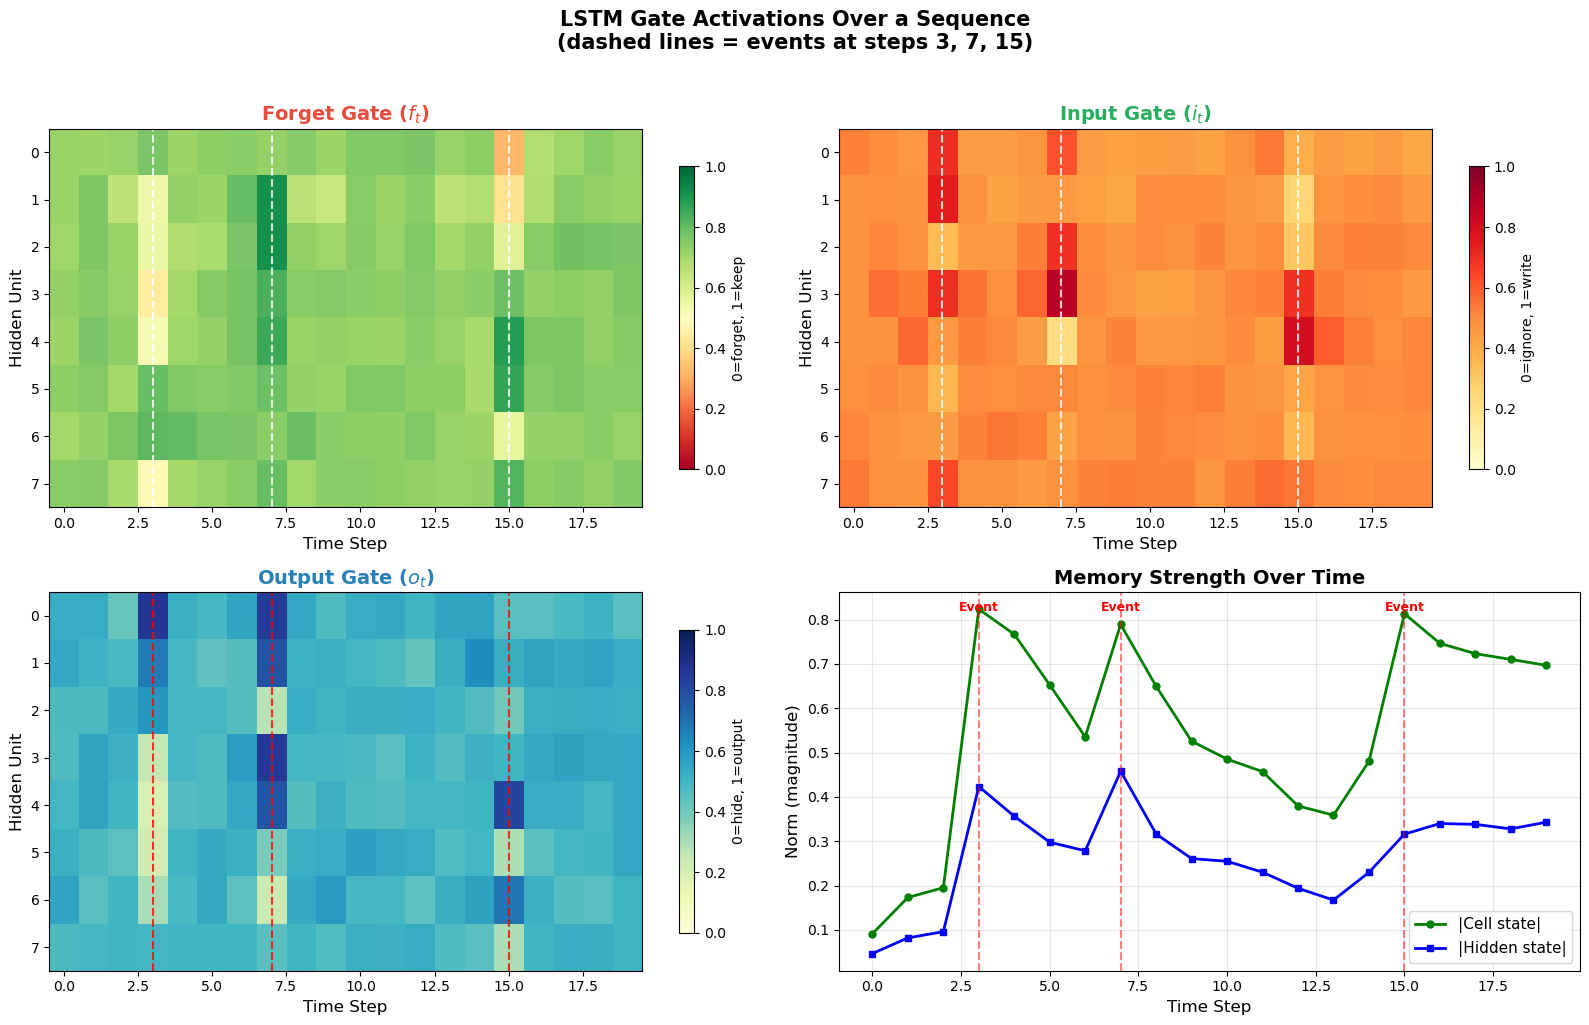


💡 What to notice:
   • Forget gate (top-left): Green = keeping memory, Red = forgetting
   • Input gate (top-right): Brighter at events = writing new info to memory
   • Output gate (bottom-left): Controls how much of the cell state gets exposed
   • Memory strength (bottom-right): Cell state grows when events occur, persists between them


In [24]:
# Visualize gate activations over the sequence

np.random.seed(42)

input_size_viz = 5
hidden_size_viz = 8
seq_len_viz = 20

# Create a sequence with two "events" separated by noise
X_viz = np.random.randn(seq_len_viz, input_size_viz) * 0.2  # low noise
X_viz[3] = np.array([3.0, 0.0, 0.0, 0.0, 0.0])   # Event A at step 3
X_viz[7] = np.array([0.0, 3.0, 0.0, 0.0, 0.0])   # Event B at step 7
X_viz[15] = np.array([0.0, 0.0, 3.0, 0.0, 0.0])  # Event C at step 15

lstm_viz = LSTMCell(input_size_viz, hidden_size_viz)
hidden_states_viz, cell_states_viz, gates_viz = lstm_viz.forward_sequence(X_viz)

# Extract gate values over time
forget_gates = np.array([g['f'] for g in gates_viz])   # (seq_len, hidden_size)
input_gates = np.array([g['i'] for g in gates_viz])
output_gates = np.array([g['o'] for g in gates_viz])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Forget Gate
im1 = axes[0, 0].imshow(forget_gates.T, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
axes[0, 0].set_title('Forget Gate ($f_t$)', fontsize=14, fontweight='bold', color='#E74C3C')
axes[0, 0].set_xlabel('Time Step', fontsize=12)
axes[0, 0].set_ylabel('Hidden Unit', fontsize=12)
plt.colorbar(im1, ax=axes[0, 0], shrink=0.8, label='0=forget, 1=keep')
for event_t in [3, 7, 15]:
    axes[0, 0].axvline(x=event_t, color='white', linestyle='--', linewidth=1.5, alpha=0.8)

# Plot 2: Input Gate
im2 = axes[0, 1].imshow(input_gates.T, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
axes[0, 1].set_title('Input Gate ($i_t$)', fontsize=14, fontweight='bold', color='#27AE60')
axes[0, 1].set_xlabel('Time Step', fontsize=12)
axes[0, 1].set_ylabel('Hidden Unit', fontsize=12)
plt.colorbar(im2, ax=axes[0, 1], shrink=0.8, label='0=ignore, 1=write')
for event_t in [3, 7, 15]:
    axes[0, 1].axvline(x=event_t, color='white', linestyle='--', linewidth=1.5, alpha=0.8)

# Plot 3: Output Gate
im3 = axes[1, 0].imshow(output_gates.T, aspect='auto', cmap='YlGnBu', vmin=0, vmax=1)
axes[1, 0].set_title('Output Gate ($o_t$)', fontsize=14, fontweight='bold', color='#2980B9')
axes[1, 0].set_xlabel('Time Step', fontsize=12)
axes[1, 0].set_ylabel('Hidden Unit', fontsize=12)
plt.colorbar(im3, ax=axes[1, 0], shrink=0.8, label='0=hide, 1=output')
for event_t in [3, 7, 15]:
    axes[1, 0].axvline(x=event_t, color='red', linestyle='--', linewidth=1.5, alpha=0.8)

# Plot 4: Cell State magnitude
cell_norms = np.linalg.norm(cell_states_viz, axis=1)
hidden_norms = np.linalg.norm(hidden_states_viz, axis=1)
axes[1, 1].plot(cell_norms, 'g-o', markersize=5, linewidth=2, label='|Cell state|')
axes[1, 1].plot(hidden_norms, 'b-s', markersize=5, linewidth=2, label='|Hidden state|')
axes[1, 1].set_title('Memory Strength Over Time', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Time Step', fontsize=12)
axes[1, 1].set_ylabel('Norm (magnitude)', fontsize=12)
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)
for event_t in [3, 7, 15]:
    axes[1, 1].axvline(x=event_t, color='red', linestyle='--', linewidth=1.5, alpha=0.5)
    axes[1, 1].text(event_t, axes[1, 1].get_ylim()[1]*0.95, f'Event', fontsize=9,
                    ha='center', color='red', fontweight='bold')

plt.suptitle('LSTM Gate Activations Over a Sequence\n'
             '(dashed lines = events at steps 3, 7, 15)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 What to notice:")
print("   \u2022 Forget gate (top-left): Green = keeping memory, Red = forgetting")
print("   \u2022 Input gate (top-right): Brighter at events = writing new info to memory")
print("   \u2022 Output gate (bottom-left): Controls how much of the cell state gets exposed")
print("   \u2022 Memory strength (bottom-right): Cell state grows when events occur, persists between them")

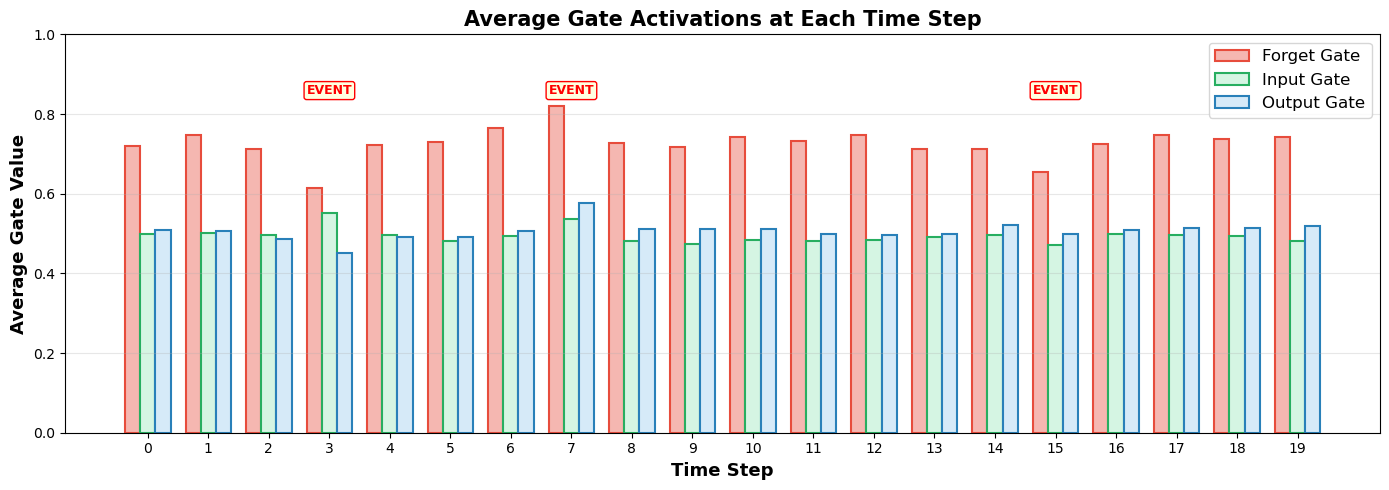


💡 Reading this chart:
   • High forget gate = KEEP existing memory
   • High input gate = WRITE new information
   • High output gate = EXPOSE memory to the next layer
   • Notice how gates change their behavior at event steps vs noise steps!


In [25]:
# Detailed view: average gate values per step

fig, ax = plt.subplots(figsize=(14, 5))

avg_forget = forget_gates.mean(axis=1)
avg_input = input_gates.mean(axis=1)
avg_output = output_gates.mean(axis=1)

x_range = range(seq_len_viz)
width = 0.25

bars1 = ax.bar([x - width for x in x_range], avg_forget, width, label='Forget Gate',
               color='#F5B7B1', edgecolor='#E74C3C', linewidth=1.5)
bars2 = ax.bar(x_range, avg_input, width, label='Input Gate',
               color='#D5F5E3', edgecolor='#27AE60', linewidth=1.5)
bars3 = ax.bar([x + width for x in x_range], avg_output, width, label='Output Gate',
               color='#D6EAF8', edgecolor='#2980B9', linewidth=1.5)

# Mark events
for event_t in [3, 7, 15]:
    ax.annotate('EVENT', xy=(event_t, 0.85), fontsize=9, fontweight='bold',
                color='red', ha='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', edgecolor='red'))

ax.set_xlabel('Time Step', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Gate Value', fontsize=13, fontweight='bold')
ax.set_title('Average Gate Activations at Each Time Step', fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.0)
ax.set_xticks(range(seq_len_viz))

plt.tight_layout()
plt.show()

print("\n💡 Reading this chart:")
print("   \u2022 High forget gate = KEEP existing memory")
print("   \u2022 High input gate = WRITE new information")
print("   \u2022 High output gate = EXPOSE memory to the next layer")
print("   \u2022 Notice how gates change their behavior at event steps vs noise steps!")

---

## ⚔️ Part 8: LSTM vs Vanilla RNN — Gradient Flow Comparison

Let's do a direct comparison. We'll build both a vanilla RNN and an LSTM, feed them the same long sequence, and compare how well gradients flow backwards through time.

⚔️ GRADIENT FLOW COMPARISON: Vanilla RNN vs LSTM



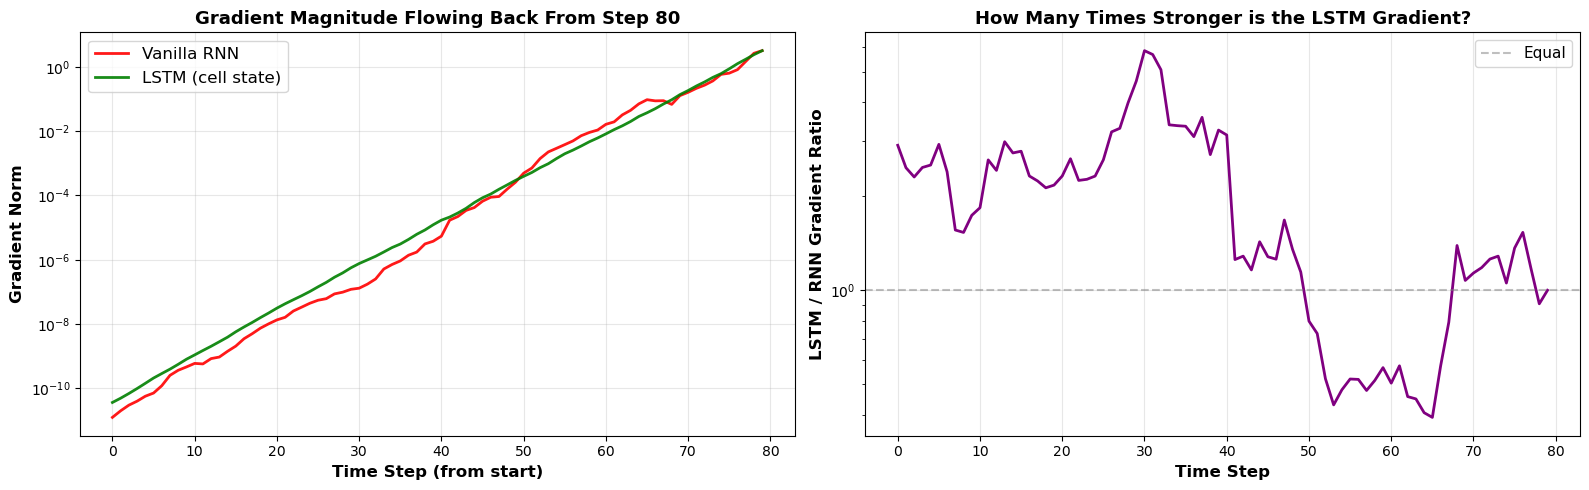


📊 Results after 80 steps:
   Vanilla RNN gradient norm at step 0: 1.26e-11
   LSTM gradient norm at step 0:        0.0000
   LSTM gradient is 2.9e+00x stronger!

💡 The LSTM's cell state highway preserves gradients FAR better than the vanilla RNN.
   This is why LSTMs can learn long-range dependencies!


In [26]:
class VanillaRNNCell:
    """A simple vanilla RNN cell for comparison with LSTM."""
    
    def __init__(self, input_size, hidden_size):
        self.hidden_size = hidden_size
        scale_xh = np.sqrt(2.0 / (input_size + hidden_size))
        scale_hh = np.sqrt(2.0 / (hidden_size + hidden_size))
        self.W_xh = np.random.randn(hidden_size, input_size) * scale_xh
        self.W_hh = np.random.randn(hidden_size, hidden_size) * scale_hh
        self.b = np.zeros(hidden_size)
    
    def forward_sequence(self, X):
        """Run the RNN and return hidden states and tanh derivatives at each step."""
        seq_len = X.shape[0]
        h = np.zeros(self.hidden_size)
        hidden_states = []
        tanh_derivs = []  # for gradient analysis
        
        for t in range(seq_len):
            pre_activation = self.W_xh @ X[t] + self.W_hh @ h + self.b
            h = np.tanh(pre_activation)
            hidden_states.append(h.copy())
            tanh_derivs.append(1 - h**2)  # derivative of tanh
        
        return np.array(hidden_states), np.array(tanh_derivs)


print("⚔\ufe0f GRADIENT FLOW COMPARISON: Vanilla RNN vs LSTM\n")
print("="*70)

np.random.seed(42)
input_size_cmp = 5
hidden_size_cmp = 10
seq_len_cmp = 80

X_cmp = np.random.randn(seq_len_cmp, input_size_cmp) * 0.5

# Run vanilla RNN
rnn = VanillaRNNCell(input_size_cmp, hidden_size_cmp)
rnn_states, rnn_tanh_derivs = rnn.forward_sequence(X_cmp)

# Run LSTM
lstm_cmp = LSTMCell(input_size_cmp, hidden_size_cmp)
lstm_states, lstm_cells, lstm_gates_cmp = lstm_cmp.forward_sequence(X_cmp)

# Compute approximate gradient flow backwards from the last step
# Vanilla RNN: gradient at step t = product of (tanh' * W_hh) from t to T
# Simplified: we track the norm of the accumulated Jacobian product

# For vanilla RNN: approximate gradient factor at each step
rnn_grad_factors = []
grad = np.ones(hidden_size_cmp)
rnn_grad_factors.append(np.linalg.norm(grad))
for t in range(seq_len_cmp - 1, 0, -1):
    # Gradient passes through: diag(tanh_deriv) @ W_hh
    grad = (rnn_tanh_derivs[t] * grad) @ rnn.W_hh
    rnn_grad_factors.append(np.linalg.norm(grad))
rnn_grad_factors = rnn_grad_factors[::-1]  # reverse to be in forward order

# For LSTM: gradient through cell state is just product of forget gates
forget_gates_cmp = np.array([g['f'] for g in lstm_gates_cmp])
lstm_grad_factors = []
grad_lstm = np.ones(hidden_size_cmp)
lstm_grad_factors.append(np.linalg.norm(grad_lstm))
for t in range(seq_len_cmp - 1, 0, -1):
    grad_lstm = forget_gates_cmp[t] * grad_lstm  # just multiply by forget gate!
    lstm_grad_factors.append(np.linalg.norm(grad_lstm))
lstm_grad_factors = lstm_grad_factors[::-1]

# Normalize for comparison
rnn_grad_norm = np.array(rnn_grad_factors) / (rnn_grad_factors[len(rnn_grad_factors)//2] + 1e-10)
lstm_grad_norm = np.array(lstm_grad_factors) / (lstm_grad_factors[len(lstm_grad_factors)//2] + 1e-10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Raw gradient norms
axes[0].plot(rnn_grad_factors, 'r-', linewidth=2, label='Vanilla RNN', alpha=0.9)
axes[0].plot(lstm_grad_factors, 'g-', linewidth=2, label='LSTM (cell state)', alpha=0.9)
axes[0].set_xlabel('Time Step (from start)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Gradient Norm', fontsize=12, fontweight='bold')
axes[0].set_title('Gradient Magnitude Flowing Back From Step 80', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Gradient ratio
ratio = np.array(lstm_grad_factors) / (np.array(rnn_grad_factors) + 1e-20)
axes[1].plot(ratio, 'purple', linewidth=2)
axes[1].set_xlabel('Time Step', fontsize=12, fontweight='bold')
axes[1].set_ylabel('LSTM / RNN Gradient Ratio', fontsize=12, fontweight='bold')
axes[1].set_title('How Many Times Stronger is the LSTM Gradient?', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')
axes[1].axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Equal')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"\n📊 Results after {seq_len_cmp} steps:")
print(f"   Vanilla RNN gradient norm at step 0: {rnn_grad_factors[0]:.2e}")
print(f"   LSTM gradient norm at step 0:        {lstm_grad_factors[0]:.4f}")
if rnn_grad_factors[0] > 1e-15:
    print(f"   LSTM gradient is {lstm_grad_factors[0] / rnn_grad_factors[0]:.1e}x stronger!")
else:
    print(f"   Vanilla RNN gradient has effectively vanished!")
print(f"\n💡 The LSTM's cell state highway preserves gradients FAR better than the vanilla RNN.")
print(f"   This is why LSTMs can learn long-range dependencies!")

---

## 🎯 Part 9: Practical Example — Remembering a Distant Signal

Let's put LSTM to a real test. We'll create a task where:

1. A **signal** appears at the very beginning of a sequence (step 0)
2. Many **noise** steps follow
3. At the **end**, we need to output something based on the original signal

This directly tests long-range memory. The vanilla RNN should struggle, while the LSTM should do much better.

🎯 PRACTICAL TEST: Remembering a Distant Signal


Task: A signal appears at step 0. After N noise steps,
      how much information about the signal remains in the hidden state?
      We measure this using the correlation between the final hidden
      state and the original signal.


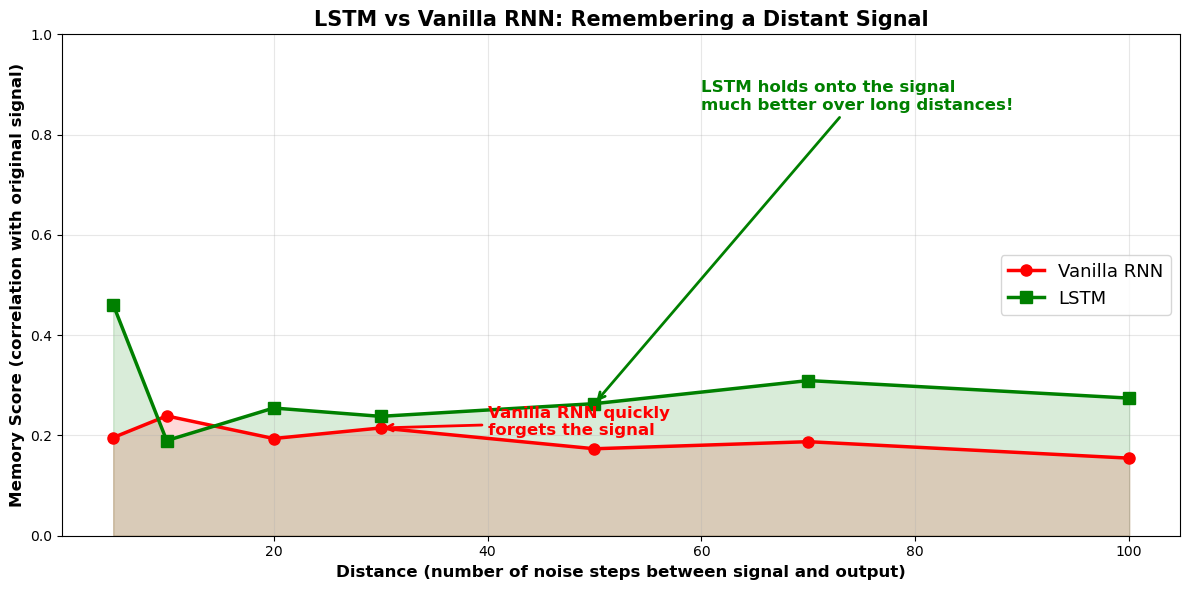


📊 Memory Scores (higher = better memory):
  Distance     Vanilla RNN       LSTM     Winner
--------------------------------------------------
         5           0.196      0.461       LSTM
        10           0.239      0.190        RNN
        20           0.194      0.255       LSTM
        30           0.215      0.238       LSTM
        50           0.173      0.263       LSTM
        70           0.188      0.309       LSTM
       100           0.155      0.274       LSTM


In [27]:
# Practical test: How well do LSTM and vanilla RNN remember a distant signal?

print("🎯 PRACTICAL TEST: Remembering a Distant Signal\n")
print("="*70)
print("\nTask: A signal appears at step 0. After N noise steps,")
print("      how much information about the signal remains in the hidden state?")
print("      We measure this using the correlation between the final hidden")
print("      state and the original signal.")
print("="*70)

np.random.seed(42)

input_size_test = 5
hidden_size_test = 20
n_trials = 50  # average over multiple random signals

distances = [5, 10, 20, 30, 50, 70, 100]

rnn_memory_scores = []
lstm_memory_scores = []

for dist in distances:
    rnn_scores = []
    lstm_scores = []
    
    for trial in range(n_trials):
        # Create sequence: strong signal at step 0, then noise
        signal = np.random.randn(input_size_test) * 2.0
        noise = np.random.randn(dist, input_size_test) * 0.1
        sequence = np.vstack([signal.reshape(1, -1), noise])
        
        # Vanilla RNN
        rnn_test = VanillaRNNCell(input_size_test, hidden_size_test)
        rnn_hidden, _ = rnn_test.forward_sequence(sequence)
        # How correlated is the final hidden state with the signal?
        rnn_corr = np.abs(np.corrcoef(rnn_hidden[-1], rnn_hidden[0])[0, 1])
        rnn_scores.append(rnn_corr)
        
        # LSTM
        lstm_test = LSTMCell(input_size_test, hidden_size_test)
        lstm_hidden, lstm_cell, _ = lstm_test.forward_sequence(sequence)
        # For LSTM, check both hidden and cell state
        lstm_corr = np.abs(np.corrcoef(lstm_hidden[-1], lstm_hidden[0])[0, 1])
        lstm_scores.append(lstm_corr)
    
    rnn_memory_scores.append(np.mean(rnn_scores))
    lstm_memory_scores.append(np.mean(lstm_scores))

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(distances, rnn_memory_scores, 'r-o', markersize=8, linewidth=2.5,
        label='Vanilla RNN', zorder=3)
ax.plot(distances, lstm_memory_scores, 'g-s', markersize=8, linewidth=2.5,
        label='LSTM', zorder=3)

ax.fill_between(distances, rnn_memory_scores, alpha=0.15, color='red')
ax.fill_between(distances, lstm_memory_scores, alpha=0.15, color='green')

ax.set_xlabel('Distance (number of noise steps between signal and output)', fontsize=12, fontweight='bold')
ax.set_ylabel('Memory Score (correlation with original signal)', fontsize=12, fontweight='bold')
ax.set_title('LSTM vs Vanilla RNN: Remembering a Distant Signal', fontsize=15, fontweight='bold')
ax.legend(fontsize=13, loc='center right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.0)

ax.annotate('LSTM holds onto the signal\nmuch better over long distances!',
            xy=(50, lstm_memory_scores[4]), xytext=(60, 0.85),
            arrowprops=dict(arrowstyle='->', lw=2, color='green'),
            fontsize=12, color='green', fontweight='bold')

ax.annotate('Vanilla RNN quickly\nforgets the signal',
            xy=(30, rnn_memory_scores[3]), xytext=(40, 0.2),
            arrowprops=dict(arrowstyle='->', lw=2, color='red'),
            fontsize=12, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Memory Scores (higher = better memory):")
print(f"{'Distance':>10} {'Vanilla RNN':>15} {'LSTM':>10} {'Winner':>10}")
print("-" * 50)
for i, d in enumerate(distances):
    winner = 'LSTM' if lstm_memory_scores[i] > rnn_memory_scores[i] else 'RNN'
    print(f"{d:>10} {rnn_memory_scores[i]:>15.3f} {lstm_memory_scores[i]:>10.3f} {winner:>10}")

📊 CELL STATE PRESERVATION OVER A LONG SEQUENCE



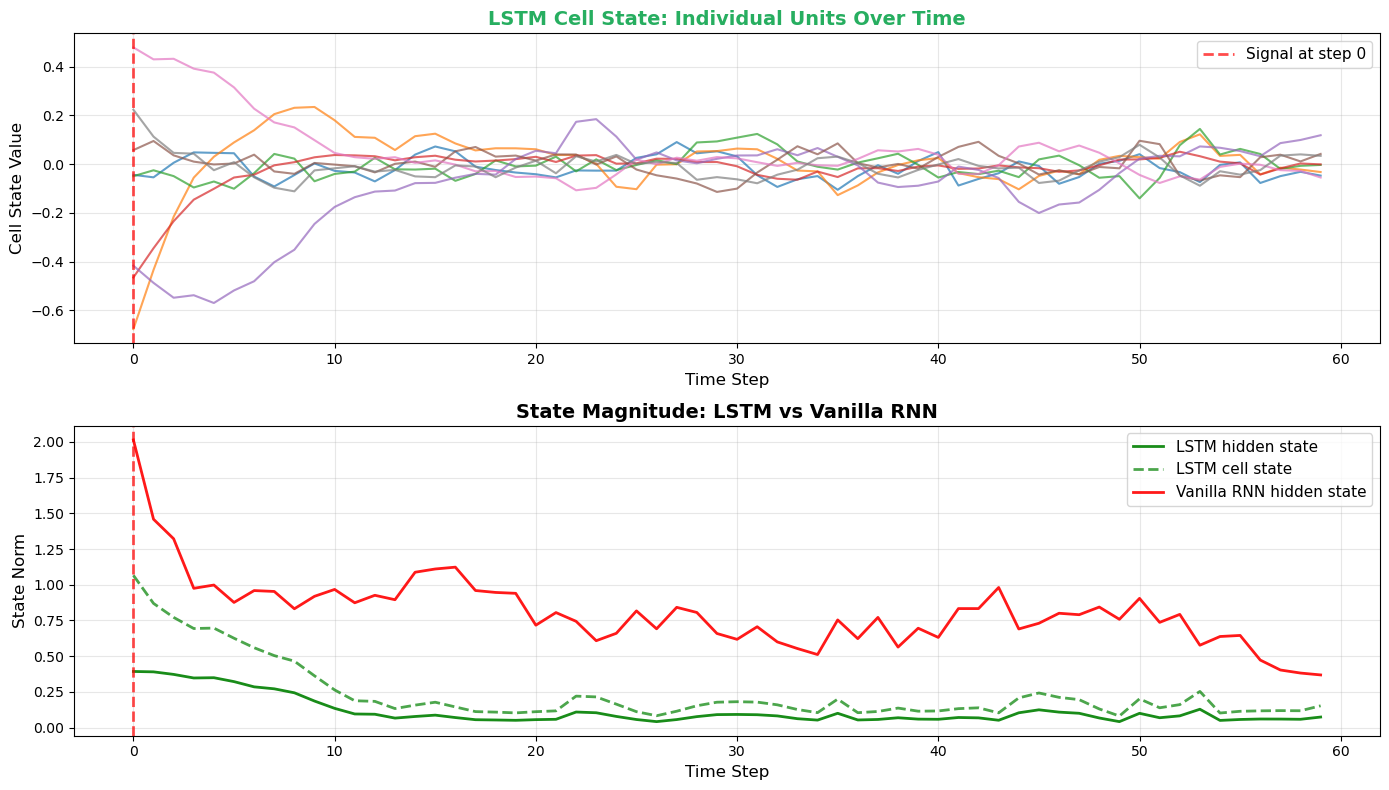


💡 What to notice:
   • Top: The LSTM cell state RETAINS information from the initial signal.
     Individual units hold stable values even after 60 steps of noise.
   • Bottom: The LSTM's cell state magnitude stays elevated long after the signal.
     Meanwhile, the vanilla RNN's hidden state quickly reaches a 'steady noise' level.
   • This is the cell state highway in action!


In [28]:
# Bonus: Visualize cell state preservation over a long sequence

np.random.seed(42)

print("📊 CELL STATE PRESERVATION OVER A LONG SEQUENCE\n")

input_size_long = 5
hidden_size_long = 8
seq_len_long = 60

# Sequence with a STRONG signal at step 0, then gentle noise
X_long = np.random.randn(seq_len_long, input_size_long) * 0.1
X_long[0] = np.array([3.0, -2.0, 1.5, -1.0, 2.0])  # Strong initial signal

lstm_long = LSTMCell(input_size_long, hidden_size_long)
h_long, c_long, gates_long = lstm_long.forward_sequence(X_long)

# Also run vanilla RNN for comparison
rnn_long = VanillaRNNCell(input_size_long, hidden_size_long)
rnn_h_long, _ = rnn_long.forward_sequence(X_long)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot each hidden unit of cell state over time
for unit in range(hidden_size_long):
    axes[0].plot(c_long[:, unit], linewidth=1.5, alpha=0.7)
axes[0].set_title('LSTM Cell State: Individual Units Over Time', fontsize=14, fontweight='bold', color='#27AE60')
axes[0].set_xlabel('Time Step', fontsize=12)
axes[0].set_ylabel('Cell State Value', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Signal at step 0')
axes[0].legend(fontsize=11)

# Compare hidden state norms: LSTM vs RNN
axes[1].plot(np.linalg.norm(h_long, axis=1), 'g-', linewidth=2, label='LSTM hidden state', alpha=0.9)
axes[1].plot(np.linalg.norm(c_long, axis=1), 'g--', linewidth=2, label='LSTM cell state', alpha=0.7)
axes[1].plot(np.linalg.norm(rnn_h_long, axis=1), 'r-', linewidth=2, label='Vanilla RNN hidden state', alpha=0.9)
axes[1].set_title('State Magnitude: LSTM vs Vanilla RNN', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time Step', fontsize=12)
axes[1].set_ylabel('State Norm', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7)

plt.tight_layout()
plt.show()

print("\n💡 What to notice:")
print("   \u2022 Top: The LSTM cell state RETAINS information from the initial signal.")
print("     Individual units hold stable values even after 60 steps of noise.")
print("   \u2022 Bottom: The LSTM's cell state magnitude stays elevated long after the signal.")
print("     Meanwhile, the vanilla RNN's hidden state quickly reaches a 'steady noise' level.")
print("   \u2022 This is the cell state highway in action!")

---

## 📝 Part 10: Summary

### 🎯 When to Use LSTM

| Situation | Use LSTM? | Why |
|-----------|-----------|-----|
| **Long sequences** (100+ steps) | ✅ Yes | LSTMs can maintain memory over hundreds of steps |
| **Short sequences** (< 10 steps) | 🤷 Maybe | A vanilla RNN might be sufficient and cheaper |
| **Need to remember specific past events** | ✅ Yes | The cell state can store and protect specific information |
| **Speed is critical** | ❌ Consider GRU | LSTMs have more parameters (4x a vanilla RNN). GRU is a faster alternative |
| **Very long sequences** (1000+ steps) | 🤔 Consider Transformers | Even LSTMs have limits. Transformers with attention can handle arbitrary-length dependencies |

### 🔑 Key Takeaways

1. **Vanilla RNNs suffer from vanishing gradients** — they cannot learn long-range dependencies because the gradient decays exponentially through `tanh` and matrix multiplications.

2. **LSTMs introduce a cell state** — a separate memory that flows through time with minimal transformation. This is the "gradient highway."

3. **Three gates control information flow:**
   - **Forget gate** ($f_t$): What old memory to erase
   - **Input gate** ($i_t$): What new information to write
   - **Output gate** ($o_t$): What memory to expose as output

4. **The cell state gradient is just the forget gate** — no matrix multiply, no tanh. If $f_t \approx 1$, gradients flow perfectly.

5. **LSTMs have 4x the parameters** of a vanilla RNN (four weight matrices instead of one), which makes them more powerful but also more expensive to train.

6. **The forget gate bias is typically initialized to 1** so the LSTM defaults to keeping memory. The network learns when to forget.

---

## 🤔 Test Your Understanding

1. **Why does the cell state help with vanishing gradients, while the hidden state in a vanilla RNN does not?**
   <details>
   <summary>Click to reveal answer</summary>
   The cell state update is C_t = f_t * C_{t-1} + i_t * C_candidate. The gradient of C_t with respect to C_{t-1} is just f_t (the forget gate) -- no matrix multiplication, no tanh. In a vanilla RNN, the gradient passes through both a tanh derivative and a weight matrix at every step, causing it to shrink exponentially.
   </details>

2. **If the forget gate is 0 and the input gate is 1, what happens to the cell state?**
   <details>
   <summary>Click to reveal answer</summary>
   The old cell state is completely erased (f_t = 0 means multiply by zero) and replaced entirely with the new candidate values. This is a "complete reset" of the memory.
   </details>

3. **Why is the forget gate bias initialized to 1 instead of 0?**
   <details>
   <summary>Click to reveal answer</summary>
   A bias of 1 means sigmoid(1) is approximately 0.73, so the LSTM starts by keeping most of the memory. If the bias were 0, sigmoid(0) = 0.5 and the network would forget half the memory by default, making it harder to learn long-range dependencies from the start.
   </details>

4. **An LSTM has input_size=10 and hidden_size=20. How many parameters does it have in total?**
   <details>
   <summary>Click to reveal answer</summary>
   Combined input size = 20 + 10 = 30. Each of the 4 gates has a weight matrix of shape (20, 30) = 600 parameters, plus a bias of 20. Total = 4 * (600 + 20) = 2,480 parameters.
   </details>

5. **What is the difference between the cell state and the hidden state in an LSTM?**
   <details>
   <summary>Click to reveal answer</summary>
   The cell state is the long-term memory that flows through time with minimal transformation (the gradient highway). The hidden state is the short-term / working memory that gets filtered through the output gate. The hidden state is what other layers see; the cell state is internal to the LSTM.
   </details>

---

## 🚀 What's Next?

Excellent work! You now understand LSTMs — one of the most important architectures in deep learning history.

But you might have noticed that LSTMs are fairly complex: three gates, a cell state, and 4x the parameters of a vanilla RNN. Is all that complexity really necessary?

In the next notebook, we'll explore the **GRU (Gated Recurrent Unit)** — a simpler alternative that merges the forget and input gates into a single "update gate" and combines the cell state with the hidden state. It often achieves similar performance to LSTMs with fewer parameters.

You'll learn:
- How GRU simplifies the LSTM design
- The reset gate and update gate
- When to choose GRU vs LSTM
- Building a GRU from scratch

**Ready for a simpler alternative?** → [Continue to Notebook 4: GRU (Gated Recurrent Unit)](04_gru.ipynb)

---

*Well done on completing Notebook 3! You're building a strong foundation in sequence modeling.*